Installing dependencies

In [2]:
!pip install tensorflow opencv-python matplotlib

In [1]:
!pip list

Package                              Version
------------------------------------ -----------
absl-py                              2.5.0
action-msgs                          1.2.3
action-tutorials-interfaces          0.20.9
action-tutorials-py                  0.20.9
actionlib-msgs                       4.9.1
actuator-msgs                        0.0.1
ament-cmake-test                     1.3.14
ament-copyright                      0.12.15
ament-cppcheck                       0.12.15
ament-cpplint                        0.12.15
ament-flake8                         0.12.15
ament-index-python                   1.4.1
ament-lint                           0.12.15
ament-lint-cmake                     0.12.15
ament-package                        0.14.2
ament-pep257                         0.12.15
ament-uncrustify                     0.12.15
ament-xmllint                        0.12.15
angles                               1.15.0
anyio                                4.14.2
argon2-cffi           

Importing stuff

In [4]:
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt

I0000 00:00:1785584037.137164   38530 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785584037.137997   38530 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785584037.168937   38530 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785584038.008156   38530 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Cleaning up dirty files

In [37]:
os.path.join('data', 'happy')
data_dir = 'data'
img_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [35]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        img_path = os.path.join(data_dir, image_class, image)

        kind = filetype.guess(img_path)

        if kind is None: 
            print(f"Unknown file type: {img_path}")
            os.remove(img_path)
            continue

        if kind.extension not in img_exts:
            print(f"Unsupported format! {img_path}")
            os.remove(img_path)
            continue

        img = cv2.imread(img_path)

        if img is None:
            print(f"Corrupted or unreadable image {img_path}")
            os.remove(img_path)
            continue

Loading the data

In [39]:
import numpy as np

In [41]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 113 files belonging to 2 classes.


E0000 00:00:1785586899.678827   38530 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [42]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

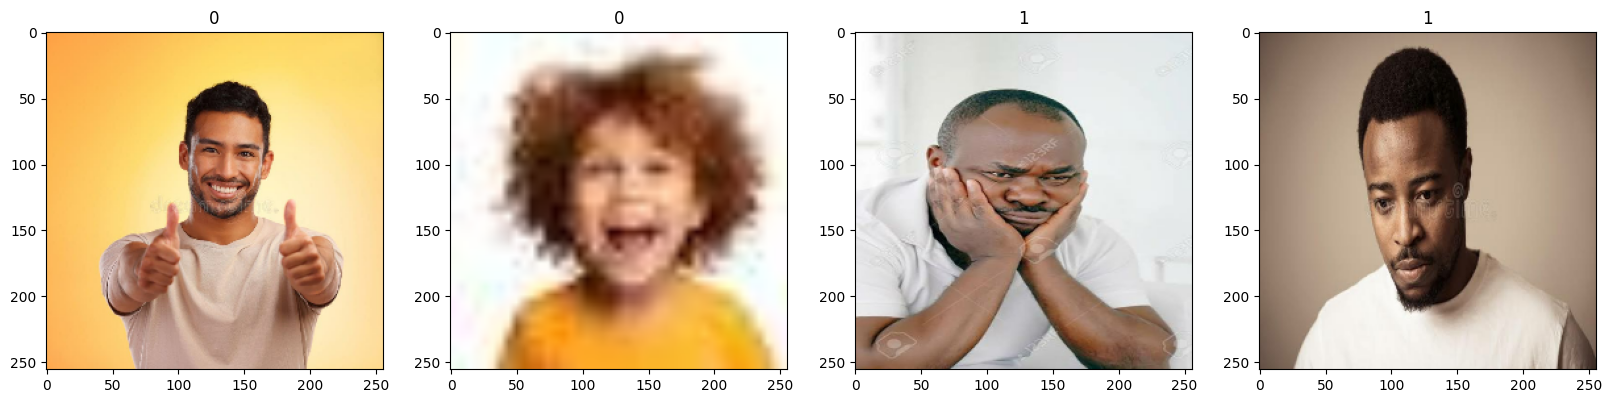

In [47]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])